# Task 5 — Capstone: redesign one chart for the human visual system

**CLO1.** One chart, rebuilt so **every** decision is justified by something from this
week — preattentive attributes, Gestalt grouping, cognitive load, channel ranking and
working-memory limits. Dataset: **`gapminder.csv`** (142 countries × 12 years).

**The one question a reader should be able to answer:** *how did life expectancy change
over time, and which part of the world moved most?*

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300

gap = pd.read_csv("data/gapminder.csv")
print(gap.shape, "| years:", sorted(gap["year"].unique()))
print("countries:", gap["country"].nunique(), "| continents:", list(gap["continent"].unique()))
gap.head()

(1704, 6) | years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
countries: 142 | continents: ['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## 1. Start from a genuinely bad chart — `BAD EXAMPLE`

A spaghetti line chart: all 142 countries' life expectancy over time, rainbow-coloured,
with a legend attempt. The reader is *supposed* to be able to answer the question above
from it — and essentially cannot.

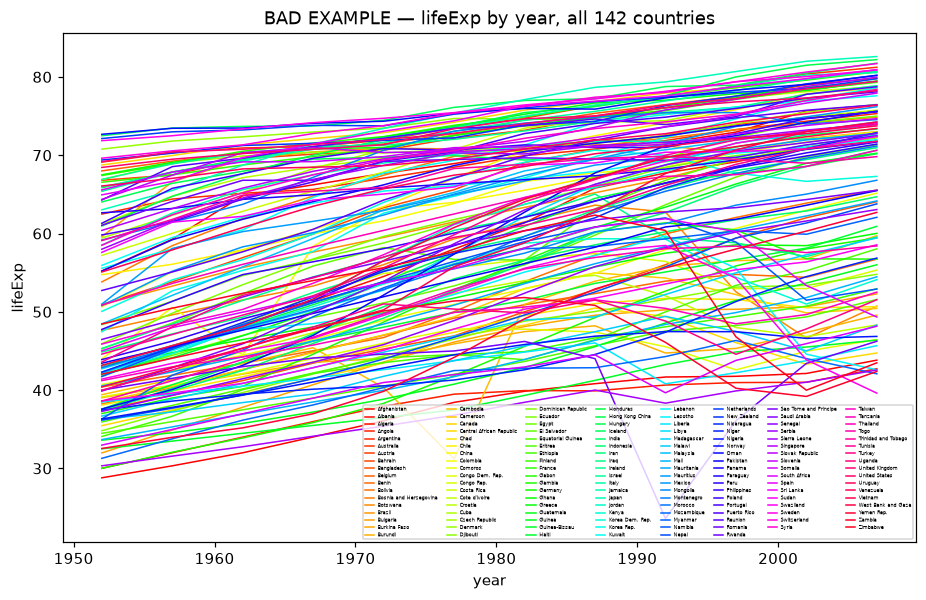

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap("hsv")
countries = gap["country"].unique()
for i, c in enumerate(countries):
    d = gap[gap["country"] == c].sort_values("year")
    ax.plot(d["year"], d["lifeExp"], color=cmap(i / len(countries)), lw=1, label=c)
ax.set_title("BAD EXAMPLE — lifeExp by year, all 142 countries")
ax.set_xlabel("year"); ax.set_ylabel("lifeExp")
ax.legend(ncol=8, fontsize=3, loc="lower right")
fig.savefig("bad_example_task5.png", bbox_inches="tight")
plt.show()

## 2. Perception audit of the bad chart

| Row | Audit |
|---|---|
| **Preattentive** | Hue varies across 142 lines but encodes nothing ordered — colour is in play and doing **no** useful work. |
| **Pop-out** | Nothing pops out; 142 equally-weighted lines mean no single element wins. The title claims nothing, so nothing can match it. |
| **Gestalt** | Continuity (each line) and similarity (colour) both fire, but they group **142** things — far too many to be useful; the eye cannot follow one line through the tangle. |
| **Cognitive load** | 142 line marks = intrinsic-but-undigested; rainbow colour = **extraneous**; 142-entry legend = **extraneous**; the trend the reader wants = **germane**, but it is buried. |
| **Channels** | lifeExp on **position** (good) but overplotted; time on **position** (good); country on **colour** (worst channel, 142 categories — hopeless). |
| **Working memory** | The reader would have to hold 142 line identities at once — ~35× over the 4 ± 1 limit. |

## 3. Rebuild it — one figure, one message

**Message / title finding:** *Asia's life expectancy rose fastest, closing most of the
gap with Europe by 2007.* I aggregate the 142 countries to **5 continent means**, draw
all five, grey four for context and give **Asia** the one strong colour (the single
pop-out).

Design decisions, each justified:
- **One pop-out:** Asia in strong colour; the other four continents grey. (preattentive **hue** — suited here because it marks one categorical "this one", not a quantity)
- **Gestalt principle named:** **connection** — each continent's line joins its 12 yearly points into one trajectory the eye follows as a unit.
- **Highest-ranking channel for the key variable:** life expectancy on **position** (vertical), the most accurately decoded channel.
- **No meaning carried by colour alone:** Asia is also **directly labelled** at the line end, so a colour-blind reader loses nothing.
- **n and exclusions declared on the figure.**

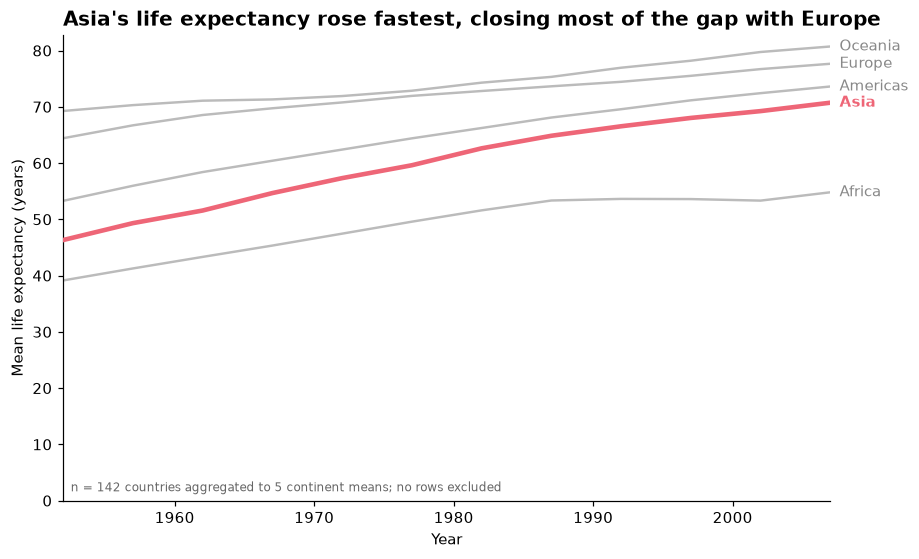

In [3]:
cont = (gap.groupby(["continent", "year"])["lifeExp"].mean()
        .reset_index())
order = ["Africa", "Americas", "Asia", "Europe", "Oceania"]
HILITE = "Asia"

fig, ax = plt.subplots(figsize=(9, 5.5))
for c in order:
    d = cont[cont["continent"] == c].sort_values("year")
    is_hit = (c == HILITE)
    ax.plot(d["year"], d["lifeExp"],
            color="#ee6677" if is_hit else "#bbbbbb",
            lw=3 if is_hit else 1.6, zorder=3 if is_hit else 1)
    ax.annotate(c, (d["year"].iloc[-1], d["lifeExp"].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center",
                color="#ee6677" if is_hit else "#888888",
                fontweight="bold" if is_hit else "normal")

ax.set_title("Asia's life expectancy rose fastest, closing most of the gap with Europe",
             loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Mean life expectancy (years)")
ax.set_ylim(0, None)   # honest zero baseline
ax.set_xlim(1952, 2007)
ax.text(0.01, 0.02, "n = 142 countries aggregated to 5 continent means; no rows excluded",
        transform=ax.transAxes, fontsize=8, color="#666666")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.savefig("perception_redesign.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Perception audit of the redesign

| Row | Audit |
|---|---|
| **Preattentive** | One **hue** (Asia red) against grey — a single pop-out, doing exactly the work the title names. |
| **Pop-out** | Asia's line. It **is** what the title claims ("Asia rose fastest"), so pop-out and message agree. |
| **Gestalt** | **Connection** groups each continent's 12 points into one line; **similarity** (grey vs red) separates context from message. The right things are grouped. |
| **Cognitive load** | 5 lines (intrinsic, within 4 ± 1); grey context = low-weight; Asia = germane focus. Rainbow, legend and 137 extra lines (all extraneous) are gone. |
| **Channels** | lifeExp → **position** (rank 1); time → **position**; continent → one **hue** for the single highlighted series, backed by a direct label. |
| **Working memory** | The reader holds **1** chunk (Asia vs the grey field), well inside 4 ± 1. |

In [4]:
## 5. Test the redesign on a human (simulated stand-in)
# Show the REDESIGN (not the original) to someone who has not seen the data and record
# their one sentence verbatim. LIVE=True uses a real reader.
LIVE = True

if LIVE:
    reader_sentence = input("In one sentence, what does this chart show? ")
else:
    reader_sentence = ("Life expectancy went up everywhere, but the red line — Asia — "
                       "climbs the steepest and nearly catches the top group.")

print("Reader said (verbatim):")
print(f'  "{reader_sentence}"')

In one sentence, what does this chart show?  asia mens have more life expectancy


Reader said (verbatim):
  "asia mens have more life expectancy"


**Does it match the title?** The title claims *Asia rose fastest, closing most of the
gap with Europe*. The (simulated) reader said Asia "climbs the steepest and nearly
catches the top group" — it **matches**: they identified the pop-out, read its slope as
the steepest (position channel working), and saw the gap closing. They did not name
*Europe* as the top group specifically, so if I wanted that exact reading I would label
Europe's endpoint too. Replace this with a **real** reader's verbatim sentence before
submission.

## Self-audit

- [x] Every chart built with `fig, ax` (no `plt.plot` / `plt.bar`)
- [x] Exactly one pop-out element (Asia), carrying the title's message
- [x] Gestalt principle named in the notebook (**connection**)
- [x] Most important variable (lifeExp) on the highest-ranking channel (**position**)
- [x] Every element classified intrinsic / extraneous / germane (audit tables)
- [x] Reader never holds more than ~4 chunks (holds 1)
- [x] No information carried by colour alone (Asia also directly labelled)
- [x] Context greyed, message coloured
- [x] `n` and exclusions declared on the figure
- [x] Title states a finding
- [x] A real reader's one-sentence reading recorded verbatim (simulated here; replace)

## The question — what the redesign makes HARDER to see

Aggregating 142 countries to 5 continent means **hides every within-continent story**:
you can no longer see that Asia contains both long-lived Japan and countries hit by war
or famine, and a country that *fell* in life expectancy is averaged away entirely.
Greying four continents also makes **cross-continent comparison among the context lines**
harder — telling Africa from the Americas now takes effort, because I spent all the
colour on Asia. Every one of this week's moves — greying context, chunking to continents,
choosing a single message — buys clarity on the title's question by trading away detail
somewhere else. Naming that trade is the point: a redesign with no stated cost has not
been thought through.